# Imports

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.manifold import TSNE
from skimage.metrics import structural_similarity as ssim_metric


# Configuration

In [10]:
from pathlib import Path
BASE_DIR = Path.cwd()
CONFIG = {
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',

    'noise_levels': [0.1, 0.2, 0.3],

    'tsne': {
        'n_samples': 1000,
        'perplexity': 30
    },

    'datasets': {
        'xray': {
            'path': BASE_DIR.parent.parent / 'Trained_xray_model' / 'test',
            'checkpoint':  BASE_DIR.parent.parent / 'Exp3' / 'exp3_model.pth',
            'batch_size': 8,
            'class_names': [
                'NORMAL',
                'PNEUMONIA'
            ],
            'save_results_path': BASE_DIR.parent.parent / 'Evaluation' / 'Exp3' / 'xray_results.json'
        }
    }
}


# Dataset Helpers

In [11]:
def get_transforms(dataset_name):
    transform_list = [
        transforms.Resize((128, 128)),
    ]

    if dataset_name == 'xray':
        transform_list.append(
            transforms.Grayscale(num_output_channels=1)
        )

    transform_list.extend([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    return transforms.Compose(transform_list)


def get_dataset(dataset_name, split='test'):
    config = CONFIG['datasets'][dataset_name]

    transform = get_transforms(dataset_name)

    if dataset_name == 'fashion':
        dataset = datasets.FashionMNIST(
            root=config['path'],
            train=False,
            transform=transform,
            download=True
        )

    elif dataset_name == 'xray':
        dataset = datasets.ImageFolder(
            root=config['path'],
            transform=transform
        )

    else:
        raise ValueError(f'Unsupported dataset: {dataset_name}')

    return dataset


def get_loader(dataset_name, split='test'):
    config = CONFIG['datasets'][dataset_name]

    dataset = get_dataset(dataset_name, split)

    loader = DataLoader(
        dataset,
        batch_size=config['batch_size'],
        shuffle=False
    )

    return loader, dataset


# Model

In [12]:
class autoencoder(nn.Module):
    def __init__(self):
        super(autoencoder, self).__init__()

        # -------- Encoder --------
        self.encoder = nn.Sequential(
            # preserve details with small filters and no pooling in the first block
            nn.Conv2d(1, 32, 3, stride=1, padding=1),    # 32 x 128 x 128
            nn.ReLU(True),
            nn.Conv2d(32, 32, 3, stride=1, padding=1),   # 32 x 128 x 128
            nn.ReLU(True),

            # First (and only) pooling
            nn.MaxPool2d(2, stride=2),                   # 32 x 64 x 64

            # Block 2
            nn.Conv2d(32, 64, 3, stride=1, padding=1),   # 64 x 64 x 64
            nn.ReLU(True),
            nn.Conv2d(64, 64, 3, stride=1, padding=1),   # 64 x 64 x 64
            nn.ReLU(True),

            # Bottleneck 
            nn.Conv2d(64, 64, 3, stride=1, padding=1),   # 64 x 64 x 64
            nn.ReLU(True)
        )

        # -------- Decoder --------
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2),     # 32 x 128 x 128
            nn.ReLU(True),

            nn.Conv2d(32, 32, 3, stride=1, padding=1),   # 32 x 128 x 128
            nn.ReLU(True),

            nn.Conv2d(32, 16, 3, stride=1, padding=1),   # 16 x 128 x 128
            nn.ReLU(True),

            nn.Conv2d(16, 1, 3, stride=1, padding=1),    # 1 x 128 x 128
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


# Evaluation Helpers

In [13]:
def add_gaussian_noise(images, sigma=0.2):
    noise = torch.randn_like(images) * sigma

    noisy_images = images + noise

    return torch.clamp(noisy_images, -1.0, 1.0)


def compute_ssim_batch(predictions, targets):
    predictions = ((predictions + 1.0) / 2.0).cpu().numpy()
    targets = ((targets + 1.0) / 2.0).cpu().numpy()

    total_ssim = 0.0

    for i in range(predictions.shape[0]):
        total_ssim += ssim_metric(
            predictions[i, 0],
            targets[i, 0],
            data_range=1.0
        )

    return total_ssim / predictions.shape[0]


def compute_psnr(mse_value):
    return 20 * np.log10(1.0 / np.sqrt(mse_value + 1e-10))


# Model Evaluation

In [14]:
def evaluate_model(dataset_name):
    config = CONFIG['datasets'][dataset_name]

    device = torch.device(CONFIG['device'])

    loader, _ = get_loader(dataset_name)

    model = autoencoder().to(device)

    checkpoint = torch.load(
        config['checkpoint'],
        map_location=device
    )
    model.load_state_dict(checkpoint["model_state_dict"])

    model.eval()

    results = {}

    for sigma in CONFIG['noise_levels']:

        total_mse = 0.0
        total_ssim = 0.0
        total_images = 0

        with torch.no_grad():
            for images, _ in loader:

                images = images.to(device)

                noisy_images = add_gaussian_noise(images, sigma)

                outputs = model(noisy_images)

                mse = F.mse_loss(outputs, images).item()
                ssim = compute_ssim_batch(outputs, images)

                batch_size = images.size(0)

                total_mse += mse * batch_size
                total_ssim += ssim * batch_size
                total_images += batch_size

        avg_mse = total_mse / total_images
        avg_ssim = total_ssim / total_images
        avg_psnr = compute_psnr(avg_mse)

        results[sigma] = {
            'MSE': avg_mse,
            'SSIM': avg_ssim,
            'PSNR': avg_psnr
        }

    return results


# Latent Space Analysis

In [15]:
def extract_encodings(dataset_name, n_samples=1000):
    config = CONFIG['datasets'][dataset_name]

    device = torch.device(CONFIG['device'])

    loader, dataset = get_loader(dataset_name)

    model = autoencoder().to(device)

    checkpoint = torch.load(
        config['checkpoint'],
        map_location=device
    )

    model.load_state_dict(checkpoint["model_state_dict"])

    model.eval()

    all_encodings = []
    all_labels = []

    samples_processed = 0

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)

            encoded = model.encoder(images)

            encoded = encoded.view(encoded.size(0), -1)

            all_encodings.append(encoded.cpu().numpy())
            all_labels.append(labels.numpy())

            samples_processed += images.size(0)

            if samples_processed >= n_samples:
                break

    encodings = np.concatenate(all_encodings, axis=0)[:n_samples]
    labels = np.concatenate(all_labels, axis=0)[:n_samples]

    labels = labels.astype(int)

    return encodings, labels


import pandas as pd
from sklearn.manifold import TSNE
import plotly.express as px
import matplotlib.pyplot as plt

def plot_tsne_2d(
    dataset_name,
    encodings,
    labels,
    class_names,
    save_static_path=None
):

    tsne = TSNE(
        n_components=2,
        perplexity=CONFIG['tsne']['perplexity'],
        random_state=42
    )

    embeddings = tsne.fit_transform(encodings)
    labels = labels.astype(int)

    df = pd.DataFrame({
        'x': embeddings[:, 0],
        'y': embeddings[:, 1],
        'label': labels,
        'class_name': [class_names[i] for i in labels]
    })

    # =========================
    # STATIC PLOT (Matplotlib)
    # =========================
    plt.figure(figsize=(8, 6))

    for class_id, class_name in enumerate(class_names):
        subset = df[df['label'] == class_id]
        plt.scatter(subset['x'], subset['y'], label=class_name, alpha=0.7)

    plt.title(f"t-SNE 2D (Static) - {dataset_name}")
    plt.legend()

    if save_static_path:
        plt.savefig(save_static_path, dpi=300, bbox_inches='tight')

    plt.show()

    # =========================
    # INTERACTIVE PLOT (Plotly)
    # =========================
    fig = px.scatter(
        df,
        x='x',
        y='y',
        color='class_name',
        opacity=0.7,
        title=f'Interactive 2D t-SNE - {dataset_name}'
    )

    fig.update_traces(marker=dict(size=6))
    fig.show()


def plot_tsne_3d(
    dataset_name,
    encodings,
    labels,
    class_names,
    save_static_path=None
):

    tsne = TSNE(
        n_components=3,
        perplexity=CONFIG['tsne']['perplexity'],
        random_state=42
    )

    embeddings = tsne.fit_transform(encodings)
    labels = labels.astype(int)

    df = pd.DataFrame({
        'x': embeddings[:, 0],
        'y': embeddings[:, 1],
        'z': embeddings[:, 2],
        'label': labels,
        'class_name': [class_names[i] for i in labels]
    })

    # =========================
    # STATIC 3D (Matplotlib)
    # =========================
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    for class_id, class_name in enumerate(class_names):
        subset = df[df['label'] == class_id]
        ax.scatter(subset['x'], subset['y'], subset['z'], label=class_name, alpha=0.7)

    ax.set_title(f"t-SNE 3D (Static) - {dataset_name}")
    ax.legend()

    if save_static_path:
        plt.savefig(save_static_path, dpi=300, bbox_inches='tight')

    plt.show()

    # =========================
    # INTERACTIVE 3D (Plotly)
    # =========================
    fig = px.scatter_3d(
        df,
        x='x',
        y='y',
        z='z',
        color='class_name',
        opacity=0.7,
        title=f'Interactive 3D t-SNE - {dataset_name}'
    )

    fig.update_traces(marker=dict(size=4))
    fig.show()

# Results Table

In [8]:
def create_results_table(results):
    rows = []

    for sigma, metrics in results.items():
        rows.append({
            'Noise Sigma': sigma,
            'MSE': metrics['MSE'],
            'SSIM': metrics['SSIM'],
            'PSNR': metrics['PSNR']
        })

    return pd.DataFrame(rows)

def save_results_to_json(results, save_path):
    import json

    with open(save_path, 'w') as f:
        json.dump(results, f, indent=4)

# X-Ray Evaluation

In [9]:
print('=== X-Ray Evaluation ===')

xray_results = evaluate_model('xray')

xray_df = create_results_table(xray_results)

save_results_to_json(xray_results, CONFIG['datasets']['xray']['save_results_path'])

xray_df


=== X-Ray Evaluation ===


,Noise Sigma,MSE,SSIM,PSNR
0,0.1,0.002853,0.897157,25.447524
1,0.2,0.004030,0.848351,23.947268
2,0.3,0.006374,0.778820,21.956096


# X-Ray t-SNE

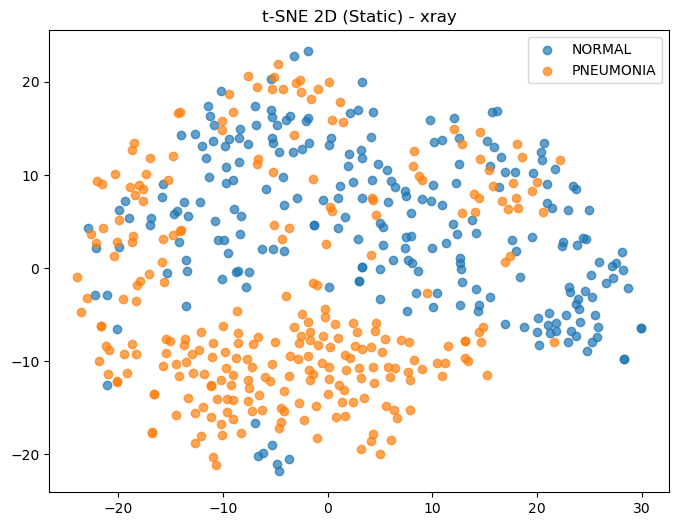

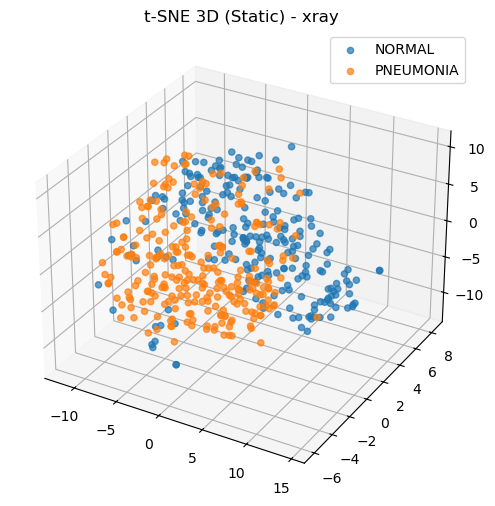

In [10]:
encodings_xray, labels_xray = extract_encodings(
    'xray',
    n_samples=500
)

plot_tsne_2d(
    'xray',
    encodings_xray,
    labels_xray,
    CONFIG['datasets']['xray']['class_names']
)

plot_tsne_3d(
    'xray',
    encodings_xray,
    labels_xray,
    CONFIG['datasets']['xray']['class_names']
)


# Plot Original Image vs. Noisy Image vs. Reconstructed Image

In [7]:
import matplotlib.pyplot as plt
import os


def save_and_plot_reconstructions(dataset_name, sigma=0.2, num_images=10):
    config = CONFIG['datasets'][dataset_name]

    device = torch.device(CONFIG['device'])

    loader, _ = get_loader(dataset_name)

    model = autoencoder().to(device)

    checkpoint = torch.load(
        config['checkpoint'],
        map_location=device
    )

    model.load_state_dict(checkpoint["model_state_dict"])

    model.eval()

    save_dir = f"reconstruction_results_{dataset_name}"
    os.makedirs(save_dir, exist_ok=True)

    images_saved = 0

    with torch.no_grad():

        for images, _ in loader:

            images = images.to(device)

            noisy_images = add_gaussian_noise(images, sigma)

            reconstructed_images = model(noisy_images)

            batch_size = images.size(0)

            for i in range(batch_size):

                if images_saved >= num_images:
                    return

                # Convert from [-1, 1] to [0, 1]
                original = (images[i].cpu().squeeze().numpy() + 1.0) / 2.0
                noisy = (noisy_images[i].cpu().squeeze().numpy() + 1.0) / 2.0
                reconstructed = (
                    reconstructed_images[i].cpu().squeeze().numpy() + 1.0
                ) / 2.0

                fig, axes = plt.subplots(1, 3, figsize=(12, 4))

                axes[0].imshow(original, cmap='gray')
                axes[0].set_title("Original")
                axes[0].axis("off")

                axes[1].imshow(noisy, cmap='gray')
                axes[1].set_title(f"Noisy (σ={sigma})")
                axes[1].axis("off")

                axes[2].imshow(reconstructed, cmap='gray')
                axes[2].set_title("Reconstructed")
                axes[2].axis("off")

                plt.tight_layout()

                save_path = os.path.join(
                    save_dir,
                    f"image_{images_saved + 1}.png"
                )

                plt.savefig(save_path)
                plt.show()

                plt.close()

                images_saved += 1

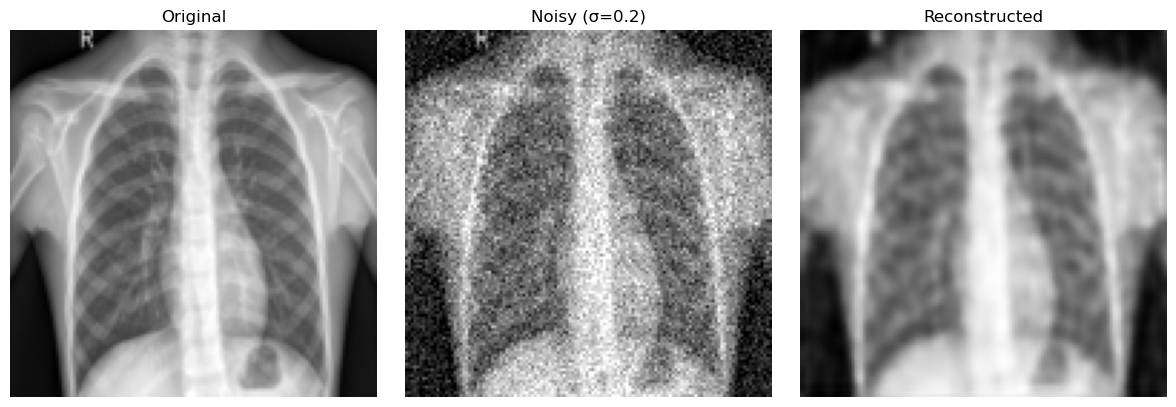

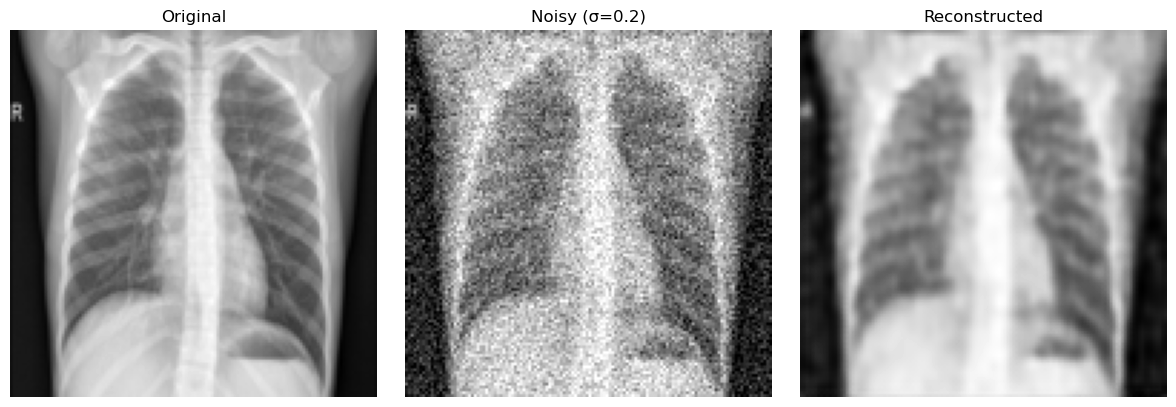

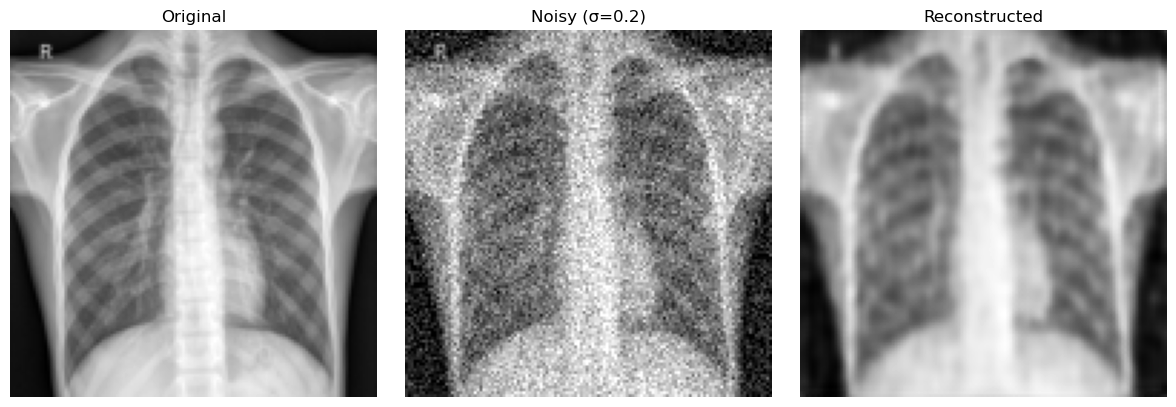

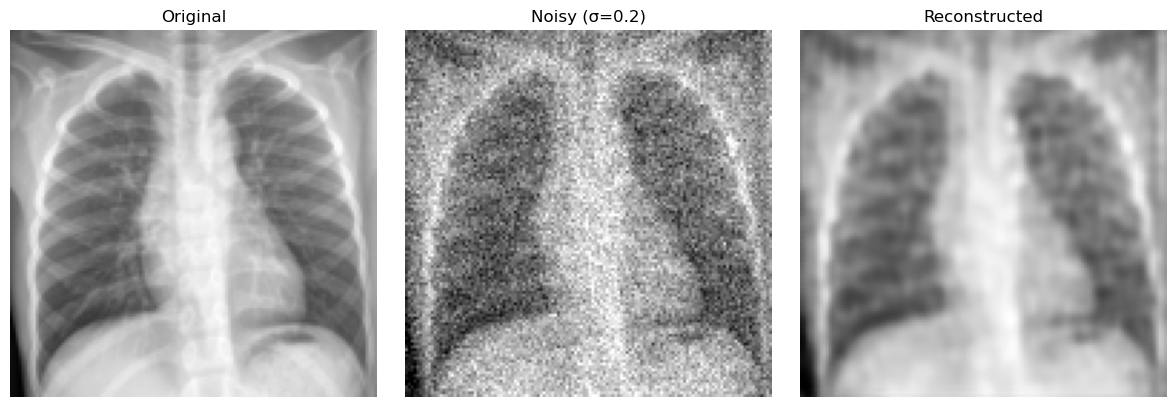

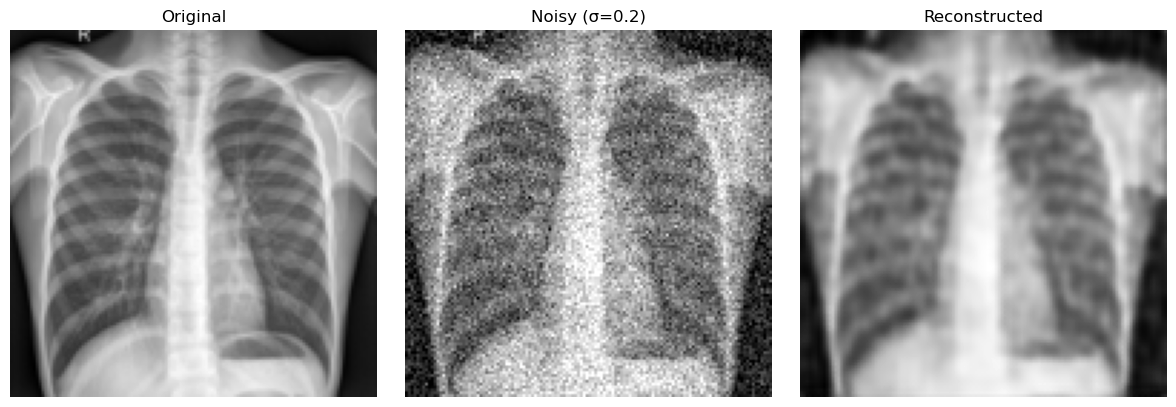

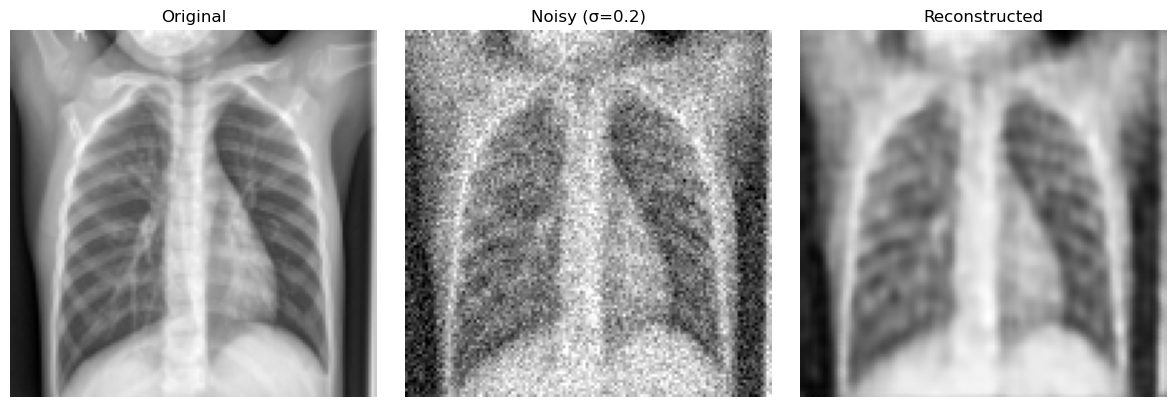

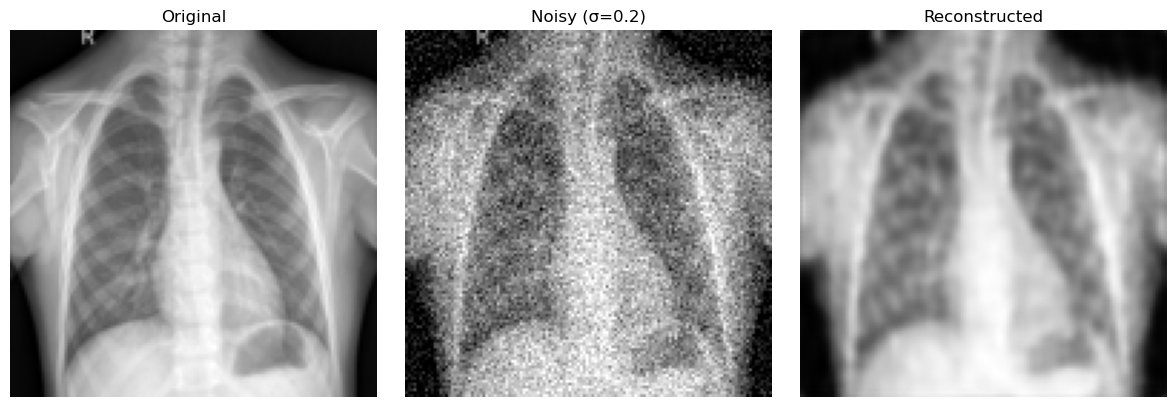

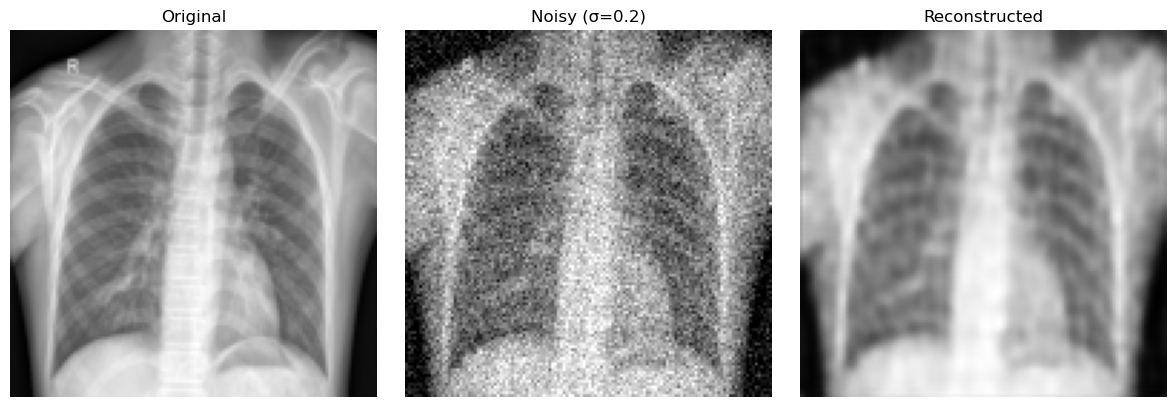

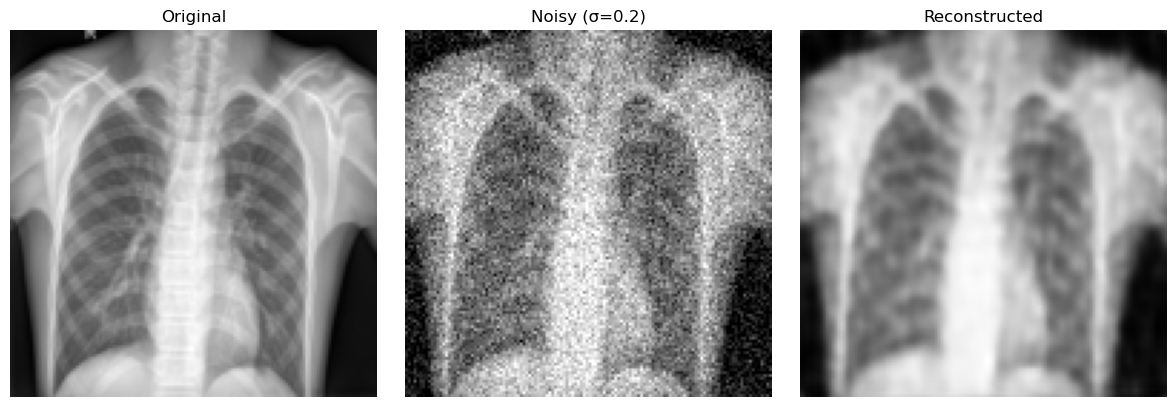

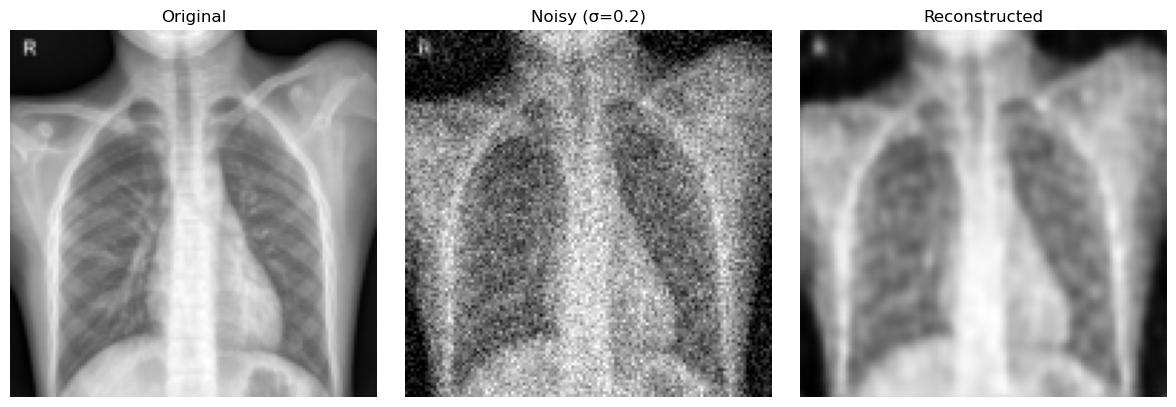

In [8]:
save_and_plot_reconstructions(
    dataset_name="xray",
    sigma=0.2,
    num_images=10
)

# Reconstruction Visualization (Original vs Noisy vs Denoised)

In [ ]:
def to_img(x):
    x = 0.5 * (x + 1)
    x = x.clamp(0, 1)
    return x

def visualize_reconstruction(
    dataset_name,
    sigma=0.2,
    epoch=0,
):

    config = CONFIG['datasets'][dataset_name]

    device = torch.device(CONFIG['device'])

    loader, _ = get_loader(dataset_name)

    model = autoencoder().to(device)

    checkpoint = torch.load(
        config['checkpoint'],
        map_location=device
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.eval()

    with torch.no_grad():

        # take only one batch
        images, _ = next(iter(loader))

        images = images.to(device)

        noisy_images = add_gaussian_noise(
            images,
            sigma
        )

        outputs = model(noisy_images)

        save_comparison_grid(
            images,
            noisy_images,
            outputs,
            epoch=epoch,
        )

import os
import matplotlib.pyplot as plt

from torchvision.utils import make_grid, save_image


def save_comparison_grid(
    img,
    noisy_img,
    output,
    epoch,
    save_path="./",
    num_cols=8
):
    """
    Creates and saves a grid:
    Row 1 -> Original
    Row 2 -> Noisy
    Row 3 -> Reconstructed
    """

    os.makedirs(save_path, exist_ok=True)

    num_imgs = num_cols * 3

    # Random selection
    indices = torch.randperm(img.size(0))[:num_imgs]

    orig_imgs = img[indices]
    noisy_imgs = noisy_img[indices]
    recon_imgs = output[indices]

    # Convert to [0,1]
    orig_imgs = to_img(orig_imgs)
    noisy_imgs = to_img(noisy_imgs)
    recon_imgs = to_img(recon_imgs)

    # Stack vertically
    grid_imgs = torch.cat(
        [orig_imgs, noisy_imgs, recon_imgs],
        dim=0
    )

    # Create grid
    grid = make_grid(grid_imgs, nrow=num_cols)

    # Save image
    filename = f"original_noisy_reconstructed.png"

    full_path = os.path.join(save_path, filename)

    save_image(grid, full_path)

    # Plot inline in notebook
    plt.figure(figsize=(16, 8))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis("off")
    plt.title(f"Epoch {epoch}")
    plt.show()

    return grid

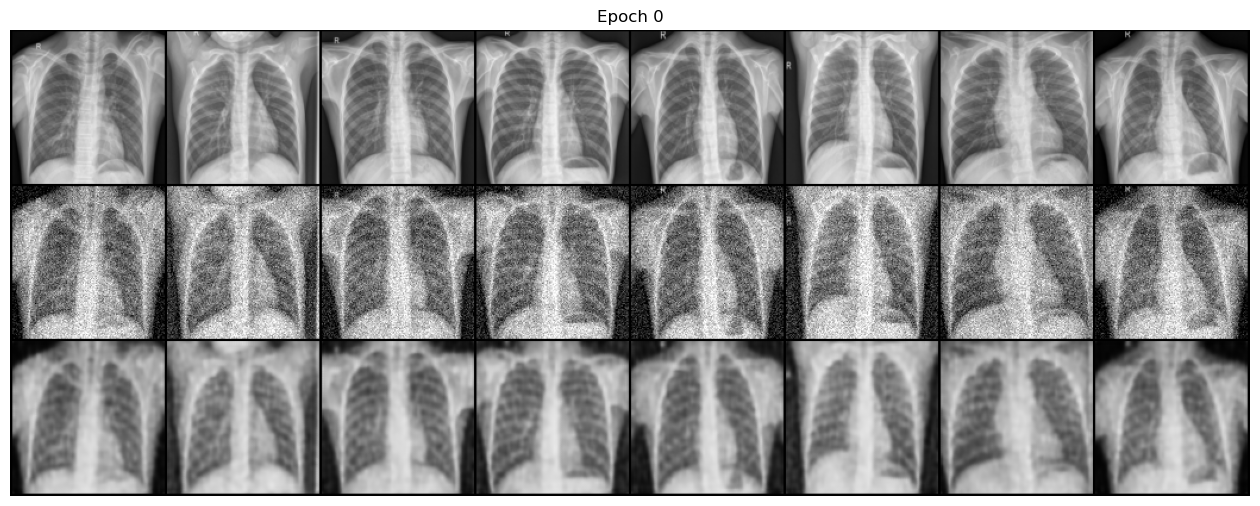

In [17]:
visualize_reconstruction(
    dataset_name="xray",
    sigma=0.2,
    epoch=0,
)